PROJECT_DIR: C:\python\Intelligent_Sketch2CAD
IMAGE_PATH: C:\python\Intelligent_Sketch2CAD\input_data\raw_sketches\WhatsApp Image 2026-04-24 at 21.41.48.jpeg
Image loaded successfully
Shape: (2048, 1152, 3)


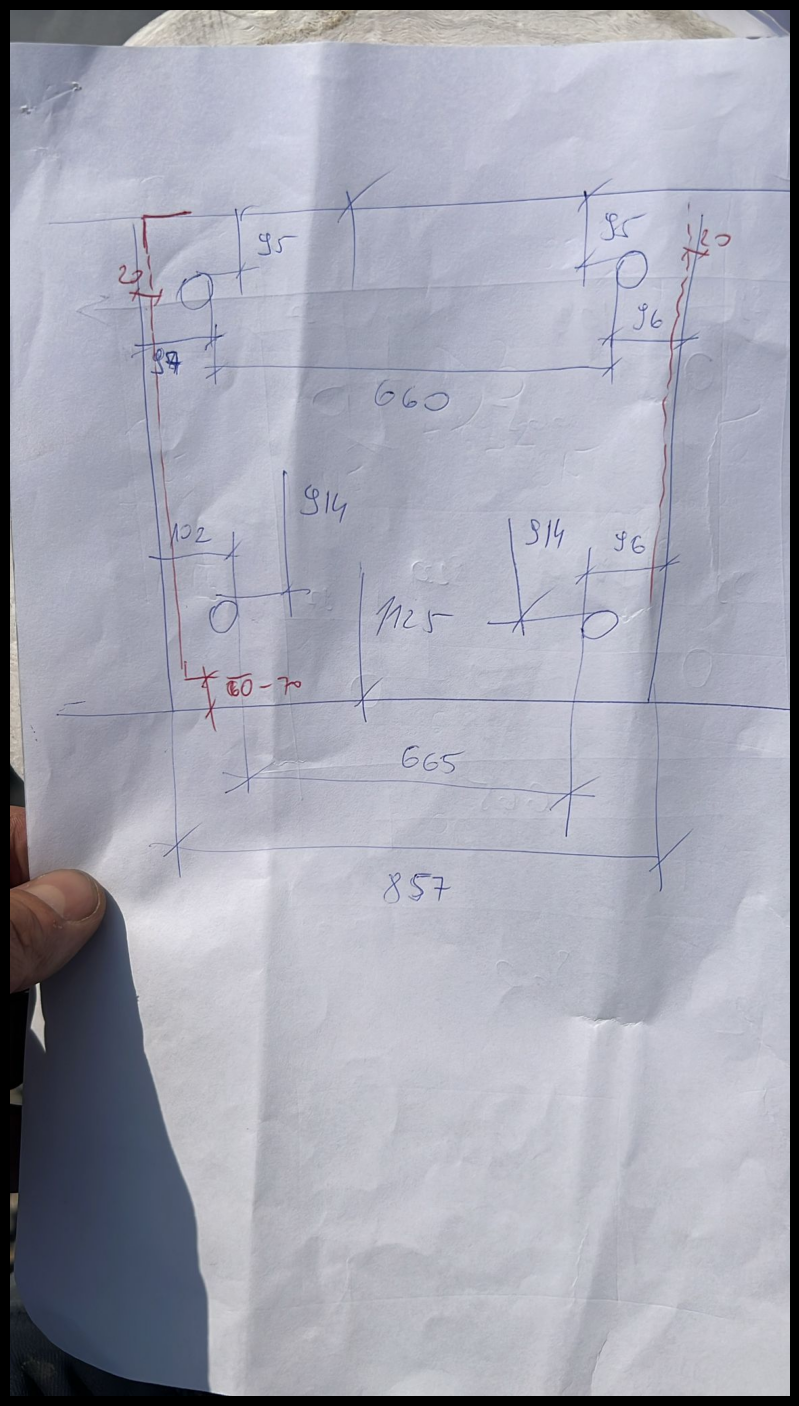


✓ Variables ready:
  - img_bgr: (2048, 1152, 3)
  - img_rgb: (2048, 1152, 3)
  - INTERMEDIATE_DIR: C:\python\Intelligent_Sketch2CAD\intermediate_data


In [2]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# --- ABSOLUTE PATHS ---
PROJECT_DIR = Path(r"/")
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
INPUT_DIR = PROJECT_DIR / "input_data"
RAW_SKETCHES_DIR = INPUT_DIR / "raw_sketches"
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
OUTPUT_DIR = PROJECT_DIR / "output_data"

# input file
IMAGE_PATH = RAW_SKETCHES_DIR / "WhatsApp Image 2026-04-24 at 21.41.48.jpeg"

# create output folders if they do not exist
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("IMAGE_PATH:", IMAGE_PATH)

# --- LOAD IMAGE ---
img_bgr = cv2.imread(str(IMAGE_PATH))

if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image loaded successfully")
print("Shape:", img_rgb.shape)

plt.figure(figsize=(12, 18))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# --- VERIFY VARIABLES ARE IN MEMORY ---
print("\n✓ Variables ready:")
print(f"  - img_bgr: {img_bgr.shape}")
print(f"  - img_rgb: {img_rgb.shape}")
print(f"  - INTERMEDIATE_DIR: {INTERMEDIATE_DIR}")

Using existing INTERMEDIATE_DIR: C:\python\Intelligent_Sketch2CAD\intermediate_data
Using device: cpu
SAM2 loaded successfully!
Generated 8 masks
Mask area: 2238192 pixels
✓ SUCCESS: Saved to C:\python\Intelligent_Sketch2CAD\intermediate_data\drawing_on_white.jpg
  Dimensions: 1152 x 2048
✓ Tight crop saved: C:\python\Intelligent_Sketch2CAD\intermediate_data\drawing_tight.jpg
  Tight dimensions: 1152 x 2022


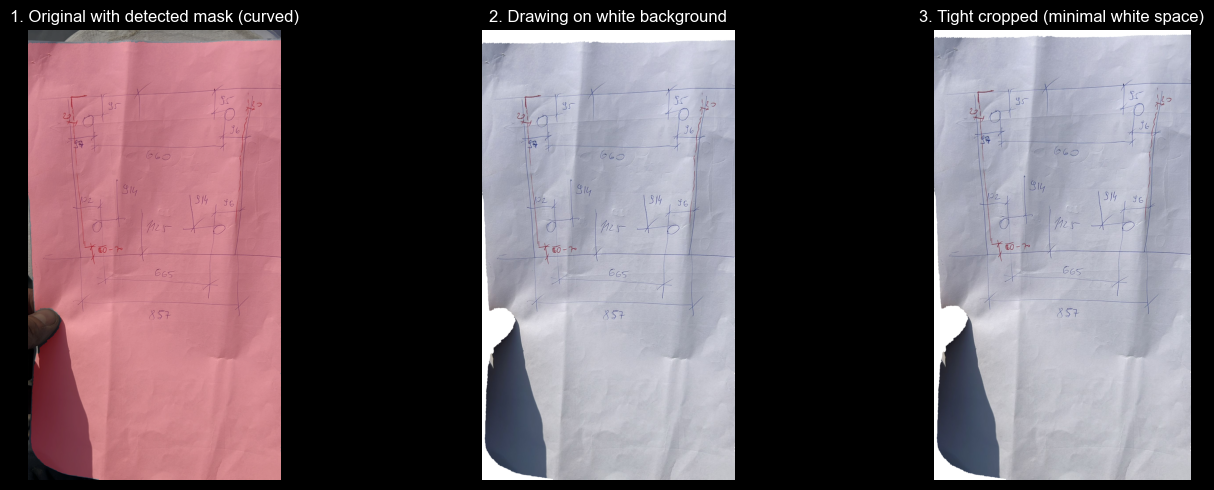


--- NEXT STEP ---
Files saved:
  - C:\python\Intelligent_Sketch2CAD\intermediate_data\drawing_on_white.jpg (drawing on white background)
  - C:\python\Intelligent_Sketch2CAD\intermediate_data\drawing_tight.jpg (tight cropped)
Ready for line and dimension extraction.


In [3]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# -------------------------------
# USE EXISTING PATHS FROM SEGMENT 1
# -------------------------------
print(f"Using existing INTERMEDIATE_DIR: {INTERMEDIATE_DIR}")

# -------------------------------
# LOAD SAM2 MODEL
# -------------------------------
checkpoint_path = "../notebooks/sam2_hiera_small.pt"
config_path = "../notebooks/sam2_hiera_s.yaml"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sam2_model = build_sam2(config_path, checkpoint_path, device=device)
predictor = SAM2ImagePredictor(sam2_model)

print("SAM2 loaded successfully!")

# -------------------------------
# PREPARE YOUR IMAGE (using img_bgr from Segment 1)
# -------------------------------
image_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
predictor.set_image(image_rgb)

# -------------------------------
# GENERATE AUTOMATIC MASKS
# -------------------------------
mask_generator = SAM2AutomaticMaskGenerator(sam2_model)
masks = mask_generator.generate(image_rgb)

print(f"Generated {len(masks)} masks")

# -------------------------------
# FIND LARGEST MASK (the paper)
# -------------------------------
masks_sorted = sorted(masks, key=lambda x: x['area'], reverse=True)
paper_mask = masks_sorted[0]

print(f"Mask area: {paper_mask['area']} pixels")

# Get the actual mask (curved shape, not bounding box)
mask = paper_mask['segmentation']  # This is the curved shape

# -------------------------------
# CREATE WHITE BACKGROUND WITH ONLY THE MASKED OBJECT
# -------------------------------
# Create white background (255 = white)
white_background = np.ones_like(image_rgb) * 255

# Copy only the masked pixels (the drawing) onto white background
white_background[mask] = image_rgb[mask]

# -------------------------------
# SAVE THE RESULT (mask on white background)
# -------------------------------
result_bgr = cv2.cvtColor(white_background, cv2.COLOR_RGB2BGR)
result_path = INTERMEDIATE_DIR / "drawing_on_white.jpg"

result = cv2.imwrite(str(result_path.absolute()), result_bgr)

if result:
    print(f"✓ SUCCESS: Saved to {result_path}")
    print(f"  Dimensions: {white_background.shape[1]} x {white_background.shape[0]}")
else:
    print(f"✗ FAILED: Could not save to {result_path}")

# -------------------------------
# OPTIONAL: Crop to the object (remove extra white space)
# -------------------------------
# Find bounding box of the mask to crop tight around the drawing
y_indices, x_indices = np.where(mask)
if len(y_indices) > 0 and len(x_indices) > 0:
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)

    # Add small padding (20 pixels)
    padding = 20
    x_min = max(0, x_min - padding)
    x_max = min(white_background.shape[1], x_max + padding)
    y_min = max(0, y_min - padding)
    y_max = min(white_background.shape[0], y_max + padding)

    # Crop tightly around the drawing
    cropped_tight = white_background[y_min:y_max, x_min:x_max]

    # Save cropped version
    tight_path = INTERMEDIATE_DIR / "drawing_tight1.jpg"
    cv2.imwrite(str(tight_path.absolute()), cv2.cvtColor(cropped_tight, cv2.COLOR_RGB2BGR))
    print(f"✓ Tight crop saved: {tight_path}")
    print(f"  Tight dimensions: {cropped_tight.shape[1]} x {cropped_tight.shape[0]}")
else:
    cropped_tight = white_background
    print("Warning: Empty mask found")

# -------------------------------
# VISUALIZATION
# -------------------------------
plt.figure(figsize=(15, 5))

# Original with mask overlay
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
mask_overlay = np.zeros_like(image_rgb)
mask_overlay[mask] = [255, 0, 0]
plt.imshow(mask_overlay, alpha=0.3)
plt.title("1. Original with detected mask (curved)")
plt.axis("off")

# Mask on white background (full size)
plt.subplot(1, 3, 2)
plt.imshow(white_background)
plt.title("2. Drawing on white background")
plt.axis("off")

# Tight cropped version
plt.subplot(1, 3, 3)
plt.imshow(cropped_tight)
plt.title("3. Tight cropped (minimal white space)")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"\n--- NEXT STEP ---")
print(f"Files saved:")
print(f"  - {result_path} (drawing on white background)")
print(f"  - {tight_path} (tight cropped)")
print(f"Ready for line and dimension extraction.")

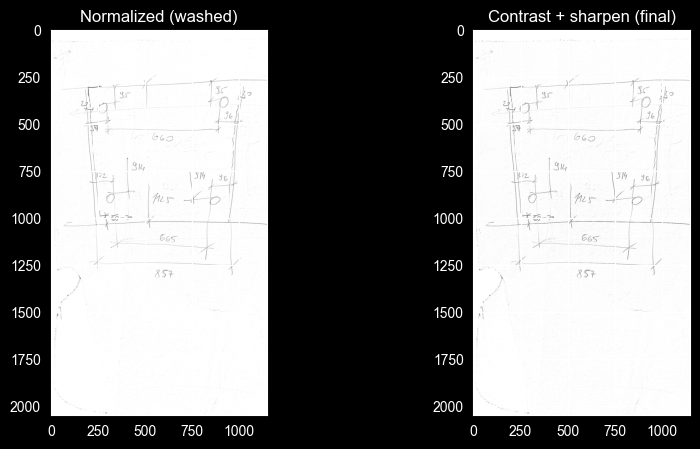

In [24]:
# -------------------------------
# STEP 1: grayscale
# -------------------------------
if len(white_background.shape) == 3:
    gray = cv2.cvtColor(white_background, cv2.COLOR_RGB2GRAY)
else:
    gray = white_background


# -------------------------------
# STEP 2: LEKKA normalizacja tła
# -------------------------------
bg = cv2.medianBlur(gray, 15)
normalized = cv2.divide(gray, bg, scale=255)


# =========================================================
# 🔧 NOWY STEP: PRZYWRÓCENIE KONTRASTU (KLUCZ)
# =========================================================
# rozciągnięcie histogramu → białe = bardziej białe, czarne = bardziej czarne

norm_float = normalized.astype(np.float32) / 255.0

# gamma < 1 → przyciemnia ciemne elementy (linie wracają)
gamma = 0.7
contrast = np.power(norm_float, gamma)

contrast = (contrast * 255).astype(np.uint8)


# =========================================================
# 🔧 OPCJONALNIE: LEKKIE WYOSTRZENIE (dla tekstu)
# =========================================================
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])

sharpened = cv2.filter2D(contrast, -1, kernel_sharp)


# -------------------------------
# VISUAL
# -------------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(normalized, cmap='gray')
plt.title("Normalized (washed)")

plt.subplot(1,2,2)
plt.imshow(sharpened, cmap='gray')
plt.title("Contrast + sharpen (final)")

plt.show()


